# Cluster Boxplot – Mean Contrast per Subject per Condition
Visualizes the mean contrast estimate within the Main Group Effect cluster, split by **Group (HC vs. MDD)** and **Condition (Primer × Target Emotion)**.

Data source: `cluster_betas_per_subject.csv` (extracted via `extract_cluster_betas.m`)

In [18]:
import sys
#!{sys.executable} -m pip install seaborn

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from scipy import stats

# Path to CSV (relative to this notebook)
csv_path = 'results/cluster_betas_per_subject.csv'

df = pd.read_csv(csv_path)
print(f"Loaded {len(df)} rows, {df['subject'].nunique()} subjects")
df.head(8)


Loaded 448 rows, 112 subjects


,subject,group,condition,mean_contrast
0,sub-004,HC,happy_primer_happy_target,0.936261
1,sub-004,HC,happy_primer_sad_target,0.623025
2,sub-004,HC,sad_primer_sad_target,1.114129
3,sub-004,HC,sad_primer_happy_target,1.096930
4,sub-006,HC,happy_primer_happy_target,2.314385
5,sub-006,HC,happy_primer_sad_target,2.287283
6,sub-006,HC,sad_primer_sad_target,2.112778
7,sub-006,HC,sad_primer_happy_target,2.282040


## Settings – condition labels & colors

In [20]:
# Condition order & readable labels
cond_order  = ['happy_primer_happy_target', 'happy_primer_sad_target',
               'sad_primer_sad_target',     'sad_primer_happy_target']
cond_labels = ['Happy–Happy', 'Happy–Sad', 'Sad–Sad', 'Sad–Happy']

group_order  = ['HC', 'MDD']
group_colors = {'HC': '#56B4E9', 'MDD': '#CC79A7'}   # light blue / pink (colorblind-friendly)

# Map to readable labels and set category order
df['condition_label'] = df['condition'].map(dict(zip(cond_order, cond_labels)))
df['condition_label'] = pd.Categorical(df['condition_label'],
                                        categories=cond_labels, ordered=True)

print("Groups:", df['group'].unique())
print("Conditions:", df['condition_label'].cat.categories.tolist())
print("n per group:", df.groupby('group')['subject'].nunique().to_dict())


Groups: ['HC' 'MDD']
Conditions: ['Happy–Happy', 'Happy–Sad', 'Sad–Sad', 'Sad–Happy']
n per group: {'HC': 59, 'MDD': 53}


## Boxplot: HC vs. MDD per condition

Grouped boxplots with individual data points (jitter). Significance brackets show independent-samples Welch's t-tests (HC vs. MDD per condition), **Bonferroni-corrected** for 4 comparisons (α = 0.05/4 = 0.0125).

`*` p < 0.0125 &nbsp;|&nbsp; `**` p < 0.0025 &nbsp;|&nbsp; `***` p < 0.00025 &nbsp;|&nbsp; `n.s.` not significant

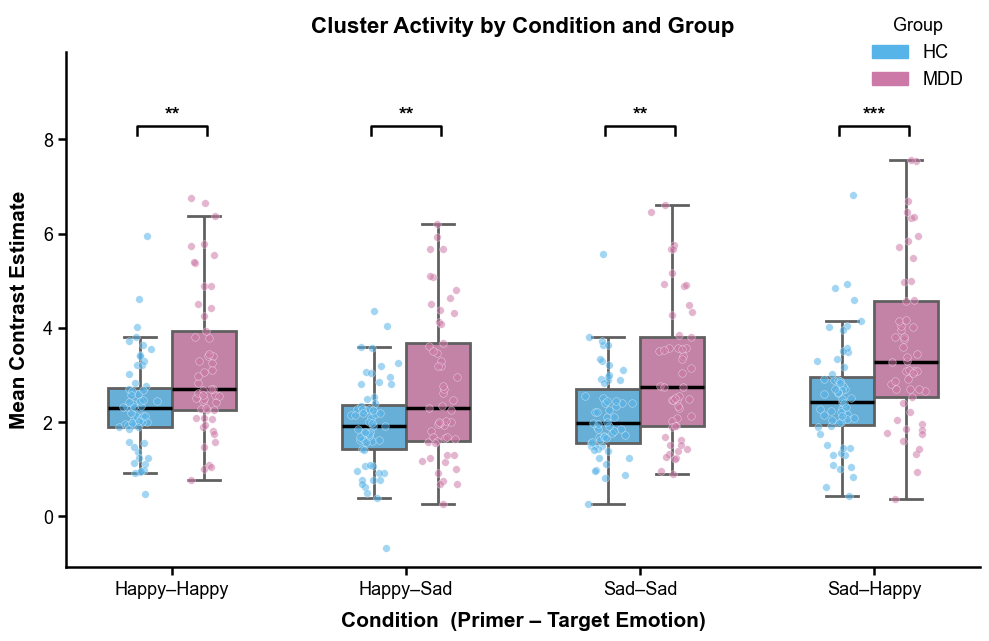

In [25]:
# ── GraphPad Prism style ──────────────────────────────────────────────────
plt.rcParams.update({
    'font.family'      : 'Arial',
    'axes.linewidth'   : 1.8,
    'xtick.major.width': 1.8,
    'ytick.major.width': 1.8,
    'xtick.major.size' : 6,
    'ytick.major.size' : 6,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

fig, ax = plt.subplots(figsize=(10, 6.5))

# Grouped boxplot
sns.boxplot(
    data           = df,
    x              = 'condition_label',
    y              = 'mean_contrast',
    hue            = 'group',
    hue_order      = group_order,
    palette        = group_colors,
    width          = 0.55,
    linewidth      = 2.0,
    fliersize      = 0,
    boxprops       = dict(linewidth=2.0),
    whiskerprops   = dict(linewidth=2.0),
    medianprops    = dict(linewidth=2.5, color='black'),
    capprops       = dict(linewidth=2.0),
    ax             = ax
)

# Jittered individual data points (larger, more opaque)
rng = np.random.default_rng(42)
for i, cond in enumerate(cond_labels):
    for j, grp in enumerate(group_order):
        vals = df[(df['condition_label'] == cond) & (df['group'] == grp)]['mean_contrast']
        offset   = -0.15 + j * 0.3
        x_jitter = rng.normal(i + offset, 0.04, size=len(vals))
        ax.scatter(x_jitter, vals,
                   color=group_colors[grp], alpha=0.55, s=30, zorder=3,
                   edgecolors='white', linewidths=0.4)

# Significance brackets – Bonferroni-corrected (4 conditions → α = 0.05/4 = 0.0125)
n_tests  = len(cond_labels)
alpha    = 0.05 / n_tests   # 0.0125

y_max  = df['mean_contrast'].max()
y_step = (df['mean_contrast'].max() - df['mean_contrast'].min()) * 0.10

for i, cond in enumerate(cond_labels):
    hc_vals  = df[(df['condition_label'] == cond) & (df['group'] == 'HC')]['mean_contrast']
    mdd_vals = df[(df['condition_label'] == cond) & (df['group'] == 'MDD')]['mean_contrast']
    _, p = stats.ttest_ind(hc_vals, mdd_vals)

    if p < 0.001 / n_tests:
        sig = '***'
    elif p < 0.01 / n_tests:
        sig = '**'
    elif p < alpha:
        sig = '*'
    else:
        sig = 'n.s.'

    y_br = y_max + y_step * 0.9
    ax.plot([i - 0.15, i - 0.15, i + 0.15, i + 0.15],
            [y_br - y_step*0.25, y_br, y_br, y_br - y_step*0.25],
            lw=1.8, color='black')
    fs = 14 if sig != 'n.s.' else 11
    ax.text(i, y_br + y_step * 0.05, sig,
            ha='center', va='bottom', fontsize=fs, fontweight='bold')

# Labels & styling
ax.set_xlabel('Condition  (Primer \u2013 Target Emotion)', fontsize=15, fontweight='bold', labelpad=10)
ax.set_ylabel('Mean Contrast Estimate', fontsize=15, fontweight='bold', labelpad=10)
ax.set_title('Cluster Activity by Condition and Group',
             fontsize=16, fontweight='bold', pad=14)
ax.set_ylim(df['mean_contrast'].min() - y_step * 0.5,
            y_max + y_step * 2.8)
ax.set_xticks(range(len(cond_labels)))
ax.set_xticklabels(cond_labels, fontsize=13)
ax.tick_params(axis='y', labelsize=13)
ax.tick_params(axis='x', labelsize=13)

legend_handles = [mpatches.Patch(color=group_colors[g], label=g) for g in group_order]
ax.legend(handles=legend_handles, title='Group', title_fontsize=13,
          fontsize=13, frameon=False,
          bbox_to_anchor=(1.0, 1.1), loc='upper right')

#ax.text(0.01, 0.01, f"Welch's t-test, Bonferroni-corrected (\u03b1\u202f=\u202f{alpha:.4f})",
#        transform=ax.transAxes, fontsize=9, color='gray', va='bottom')

sns.despine(ax=ax)
plt.tight_layout()
plt.show()


In [27]:

# ── Statistical summary table (HC vs. MDD per condition, Welch's t-test) ──
from scipy.stats import ttest_ind

n_tests   = len(cond_labels)
alpha_bon = 0.05 / n_tests   # Bonferroni-corrected alpha

rows = []
for cond in cond_labels:
    hc_vals  = df[(df['condition_label'] == cond) & (df['group'] == 'HC')]['mean_contrast'].dropna()
    mdd_vals = df[(df['condition_label'] == cond) & (df['group'] == 'MDD')]['mean_contrast'].dropna()

    t, p = ttest_ind(hc_vals, mdd_vals, equal_var=False)   # Welch's

    # Cohen's d (pooled SD)
    pooled_sd = np.sqrt((hc_vals.std(ddof=1)**2 + mdd_vals.std(ddof=1)**2) / 2)
    d = (hc_vals.mean() - mdd_vals.mean()) / pooled_sd

    # Welch-Satterthwaite df
    s1, s2, n1, n2 = hc_vals.var(ddof=1), mdd_vals.var(ddof=1), len(hc_vals), len(mdd_vals)
    df_w = (s1/n1 + s2/n2)**2 / ((s1/n1)**2/(n1-1) + (s2/n2)**2/(n2-1))

    p_corr = min(p * n_tests, 1.0)   # Bonferroni-corrected p
    sig = ('***' if p_corr < 0.001 else
           '**'  if p_corr < 0.01  else
           '*'   if p_corr < 0.05  else 'n.s.')

    rows.append({
        'Condition'        : cond,
        'n_HC'             : n1,
        'n_MDD'            : n2,
        'Mean_HC'          : round(hc_vals.mean(), 4),
        'SD_HC'            : round(hc_vals.std(ddof=1), 4),
        'Mean_MDD'         : round(mdd_vals.mean(), 4),
        'SD_MDD'           : round(mdd_vals.std(ddof=1), 4),
        't'                : round(t, 3),
        'df'               : round(df_w, 1),
        'p_uncorrected'    : round(p, 4),
        'p_Bonferroni'     : round(p_corr, 4),
        "Cohen's d"        : round(d, 3),
        'Significance'     : sig,
    })

results_df = pd.DataFrame(rows)

# pretty-print
with pd.option_context('display.float_format', '{:.4f}'.format,
                       'display.max_columns', None, 'display.width', 120):
    print(f"Welch's independent-samples t-tests (HC vs. MDD), Bonferroni-corrected (α = {alpha_bon})\n")
    print(results_df.to_string(index=False))

# save
csv_out = 'results/ttest_HC_vs_MDD_per_condition.csv'
results_df.to_csv(csv_out, index=False)
print(f'\nSaved to {csv_out}')


Welch's independent-samples t-tests (HC vs. MDD), Bonferroni-corrected (α = 0.0125)

  Condition  n_HC  n_MDD  Mean_HC  SD_HC  Mean_MDD  SD_MDD       t      df  p_uncorrected  p_Bonferroni  Cohen's d Significance
Happy–Happy    59     53   2.3526 0.9804    3.1888  1.5098 -3.4340 87.6000         0.0009        0.0036    -0.6570           **
  Happy–Sad    59     53   1.9458 0.9463    2.7278  1.5413 -3.1920 84.5000         0.0020        0.0079    -0.6110           **
    Sad–Sad    59     53   2.1671 0.9130    3.0366  1.4814 -3.6900 84.7000         0.0004        0.0016    -0.7070           **
  Sad–Happy    59     53   2.5549 1.1530    3.5970  1.6980 -3.7570 90.1000         0.0003        0.0012    -0.7180           **

Saved to results/ttest_HC_vs_MDD_per_condition.csv


## Save figure

In [26]:
out_svg = 'results/cluster_boxplot.svg'
out_png = 'results/cluster_boxplot.png'

fig.savefig(out_svg, dpi=300, bbox_inches='tight')
fig.savefig(out_png, dpi=300, bbox_inches='tight')
print(f'Saved:\n  {out_svg}\n  {out_png}')


Saved:
  results/cluster_boxplot.svg
  results/cluster_boxplot.png
